In [206]:
import numpy as np
from skimage import io
import scipy as sp

import trimesh
from trimesh import Trimesh
import pyvista as pv

import matplotlib.pyplot as plt

import numpy as np
from scipy.signal import savgol_filter

def resample_smooth(xy, step=None, window=11, poly=3):
    """Uniform-arclength resample + Savitzky-Golay smooth of a 2D polyline."""
    xy = np.asarray(xy, dtype=float)
    s = np.concatenate([[0.0], np.cumsum(np.linalg.norm(np.diff(xy, axis=0), axis=1))])

    step = step or np.median(np.diff(s))          # default: median edge length
    su = np.arange(0, s[-1], step)
    out = np.column_stack([np.interp(su, s, xy[:, i]) for i in (0, 1)])

    if window and window < len(out):
        window += (window % 2 == 0)                # force odd
        out = savgol_filter(out, window, poly, axis=0)
    return out

def polyline_curvature(xy, smooth=0):
    """Signed curvature of an open 2D polyline.

    xy     : (n, 2) ordered points
    smooth : optional Savitzky-Golay window (odd int, 0 = off)
    returns: (n,) signed curvature, 1/length units
    """
    xy = np.asarray(xy, dtype=float)
    if smooth:
        from scipy.signal import savgol_filter
        xy = savgol_filter(xy, smooth, 3, axis=0)

    # cumulative arclength as the parameter
    d = np.linalg.norm(np.diff(xy, axis=0), axis=1)
    s = np.concatenate([[0.0], np.cumsum(d)])

    dx, dy = np.gradient(xy[:, 0], s), np.gradient(xy[:, 1], s)
    ddx, ddy = np.gradient(dx, s), np.gradient(dy, s)

    return (dx * ddy - dy * ddx) / np.power(dx**2 + dy**2, 1.5)

In [221]:
mesh = np.load('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/mTmG clones/05-29-2026 mTmG clone rep2/DOB 03-22-2026/F1 tail clip/R1/0. Day 0/mesh.npz')
vertices = mesh['vertices']
faces = mesh['faces']
curvatures = mesh['values']

mesh = Trimesh(vertices,faces)
vertices.max()

np.float64(597.0531564356957)

In [232]:
pl = pv.Plotter()
pl.add_mesh(pv.wrap(mesh))
pl.show()

Widget(value='<iframe src="http://localhost:58017/index.html?ui=P_0x17ede1940_5&reconnect=auto" class="pyvista…

In [352]:
# Generate a random orthogonal plane
from numpy import random

plane_normal = [0,random.randn(1)[0],random.randn(1)[0]]

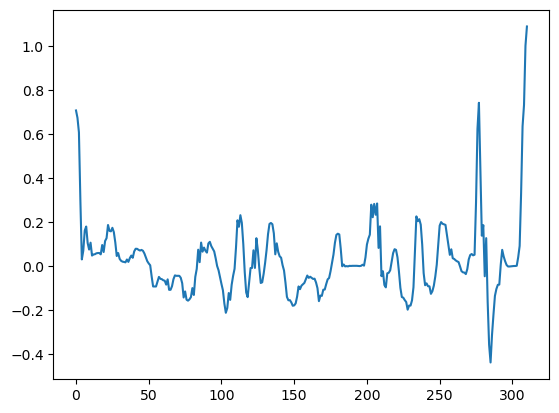

In [353]:
import numpy as np
import trimesh

# vertex_vals: (n_vertices,) or (n_vertices, k)
segs, faces = trimesh.intersections.mesh_plane(
    mesh, plane_normal, plane_origin=[0, 400, 400], return_faces=True)

pts = segs.reshape(-1, 3)                    # (2N, 3) segment endpoints
fidx = np.repeat(faces, 2)                   # face for each endpoint

bary = trimesh.triangles.points_to_barycentric(mesh.triangles[fidx], pts)
bary = np.clip(bary, 0, 1)
bary /= bary.sum(axis=1, keepdims=True)      # guard degenerate tris

corner_vals = curvatures[mesh.faces[fidx]]  # (2N, 3[, k])
if corner_vals.ndim == 2:
    pt_vals = (bary * corner_vals).sum(axis=1)
else:
    pt_vals = np.einsum('ij,ijk->ik', bary, corner_vals)

seg_vals = pt_vals.reshape(segs.shape[0], 2).mean(axis=1)  # matches segs layout

X,Y = segs[:,0,1],segs[:,0,2]
Ix = X.argsort()
plt.plot(seg_vals[Ix])

In [361]:
len(seg_vals[Ix])].shape

311

ValueError: x and y must be the same size

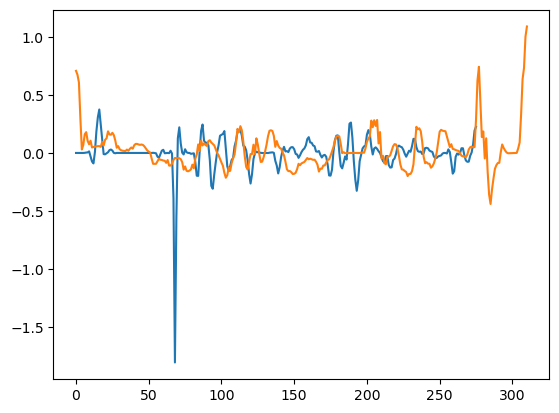

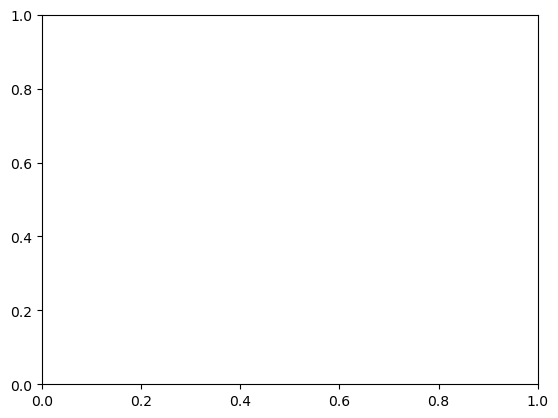

In [358]:
line = np.squeeze(segs[:,0:1,[2,0]])
# mask = line[:,1] > 50
# line = line[mask,:]
line = line[np.argsort(line[:,0]),:]

smoothed_line = resample_smooth(line)
C = polyline_curvature(smoothed_line, smooth=5)

I = smoothed_line[:,0].argsort()
# plt.scatter(smoothed_line[:,0],smoothed_line[:,1], c=C, vmax= 1,vmin=-1)
plt.plot(C[I][::2])
# plt.scatter(pts[:,0],C, vmax= 1,vmin=-1)
plt.plot(seg_vals[Ix])

plt.figure()
# plt.scatter(seg_vals[Ix],C[I][::2][:len(seg_vals[Ix])])
# print(np.corrcoef(seg_vals[Ix],C[I][::2][:300]))

array([[  2.00518177,  60.83349622],
       [  2.42899386,  59.92443063],
       [  3.01604314,  59.16648326],
       ...,
       [594.21092962,  -0.63767814],
       [594.93741614,  -1.27273055],
       [595.68661312,  -1.82226641]])

(-0.2, 0.2)

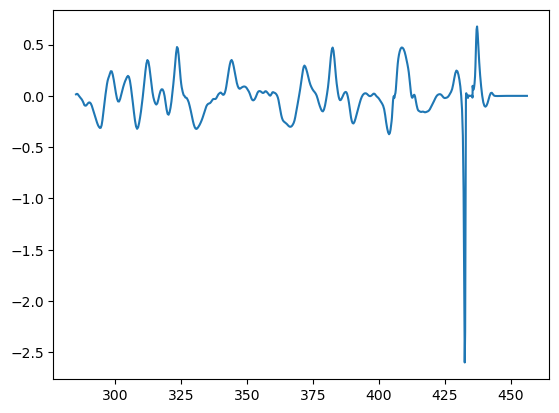

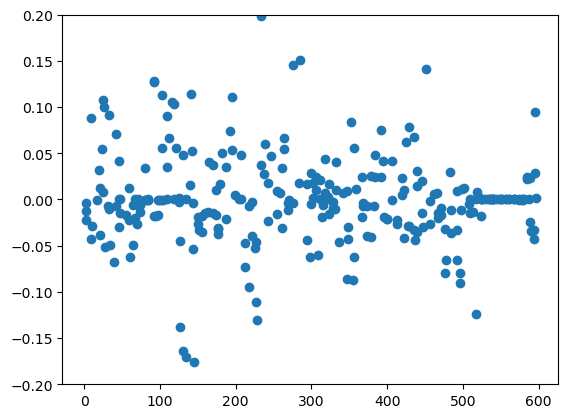

In [247]:
plt.plot(smoothed_line[:,0],C)
plt.figure()
I = intersection[:,0,1].argsort()
x = intersection[:,0,1][I]
plt.scatter(x,k[I]); plt.ylim([-.2,.2])

In [248]:
import numpy as np
from collections import defaultdict

def cross_section_values(mesh, plane_origin, plane_normal, vertex_values):
    """Ordered intersection polylines with interpolated vertex data.
    Returns list of (points (m,3), values (m,...)) in mesh coordinates."""
    n = np.asarray(plane_normal, float)
    n = n / np.linalg.norm(n)
    vals = np.asarray(vertex_values, float)

    d = (mesh.vertices - plane_origin) @ n
    d[d == 0] = 1e-12                                   # break on-plane ties

    E = mesh.edges_unique
    crossing = np.sign(d[E[:, 0]]) != np.sign(d[E[:, 1]])
    ei = np.flatnonzero(crossing)
    if len(ei) == 0:
        return []

    a, b = E[ei, 0], E[ei, 1]
    t = (d[a] / (d[a] - d[b]))[:, None]                  # edge parameter
    P = mesh.vertices[a] + t * (mesh.vertices[b] - mesh.vertices[a])
    V = vals[a] + t.reshape((-1,) + (1,) * (vals.ndim - 1)) * (vals[b] - vals[a])

    row = np.full(len(E), -1)
    row[ei] = np.arange(len(ei))                         # unique edge -> row of P

    fe = mesh.faces_unique_edges
    hit = crossing[fe]
    segs = np.array([row[fe[f][hit[f]]]
                     for f in np.flatnonzero(hit.sum(axis=1) == 2)])

    adj = defaultdict(list)
    for i, (p, q) in enumerate(segs):
        adj[p].append(i)
        adj[q].append(i)

    used, out = np.zeros(len(segs), bool), []
    for v in sorted(adj, key=lambda k: len(adj[k])):     # open ends first
        path, cur = [v], v
        while (nxt := [i for i in adj[cur] if not used[i]]):
            i = nxt[0]
            used[i] = True
            cur = segs[i, 1] if segs[i, 0] == cur else segs[i, 0]
            path.append(cur)
        if len(path) > 1:
            out.append((P[path], V[path]))
    return out